# 🎭 Multimodal Emotion Recognition
## Facial Images + Text Sentiment → Final Emotion

This notebook builds a multimodal emotion recognition system:
1. 🖼️ **Facial Emotion** via a CNN trained on FER2013-style images
2. 📝 **Text Sentiment** via VADER
3. 🔀 **Fusion** — rule-based and ML-based combination

> **Tip:** Use a GPU runtime for faster training  
> Runtime → Change runtime type → T4 GPU

In [ ]:
!pip install -q tensorflow keras opencv-python-headless numpy pandas \
             matplotlib scikit-learn nltk vaderSentiment kaggle
!pip install -q streamlit pyngrok
print("✅ All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 127.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 116.4 MB/s eta 0:00:00
✅ All libraries installed!


In [ ]:
import numpy as np
import pandas as pd
import os, cv2, re, warnings, string
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from google.colab import files
from PIL import Image
import io

np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")

✅ TensorFlow : 2.19.0
✅ GPU        : True


In [ ]:
EMOTION_LABELS = ['angry','disgust','fear','happy','sad','surprise','neutral']
NUM_CLASSES    = len(EMOTION_LABELS)
IMG_SIZE       = 48

!unzip -q Dataset.zip
!ls
df = pd.read_csv('fer2013.csv')
print(df.shape)  # should show (35887, 3)

replace fer2013.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Dataset.zip  fer2013.csv  sample_data
(35887, 3)


⚙️  Parsing images …
Train: 25134  Val: 5369  Test: 5384


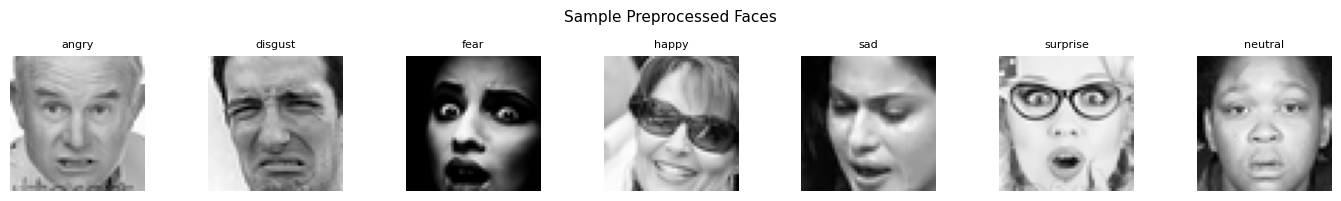

In [ ]:
def parse_pixels(s, sz=48):
    return (np.array(s.split(), np.float32) / 255.0).reshape(sz, sz, 1)

print("⚙️  Parsing images …")
X     = np.stack(df['pixels'].map(parse_pixels).values)
y_raw = df['emotion'].values
y     = to_categorical(y_raw, NUM_CLASSES)

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=42,
    stratify=y_tmp.argmax(axis=1))

print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

fig, axes = plt.subplots(1, 7, figsize=(14, 2))
for eid in range(NUM_CLASSES):
    idx = np.where(y_train.argmax(1) == eid)[0][0]
    axes[eid].imshow(X_train[idx].squeeze(), cmap='gray')
    axes[eid].set_title(EMOTION_LABELS[eid], fontsize=8)
    axes[eid].axis('off')
plt.suptitle('Sample Preprocessed Faces', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
def build_cnn(input_shape=(48,48,1), n=7):
    m = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32,(3,3),padding='same',activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32,(3,3),padding='same',activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),

        layers.Conv2D(64,(3,3),padding='same',activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64,(3,3),padding='same',activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),

        layers.Conv2D(128,(3,3),padding='same',activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2), layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(n, activation='softmax'),
    ], name='FacialEmotionCNN')
    return m

cnn_model = build_cnn()
cnn_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "FacialEmotionCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,322,855 (5.05 MB)

 Trainable params: 1,321,703 (5.04 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

print("🚀 Training CNN …")
history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=64,
    callbacks=callbacks, verbose=1)

loss, acc = cnn_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ Test Accuracy: {acc:.4f} | Loss: {loss:.4f}")

🚀 Training CNN …
Epoch 1/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.2745 - loss: 2.2630 - val_accuracy: 0.2367 - val_loss: 2.2449 - learning_rate: 0.0010
Epoch 2/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.4301 - loss: 1.4902 - val_accuracy: 0.4908 - val_loss: 1.3685 - learning_rate: 0.0010
Epoch 3/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.4914 - loss: 1.3253 - val_accuracy: 0.5357 - val_loss: 1.2795 - learning_rate: 0.0010
Epoch 4/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5280 - loss: 1.2478 - val_accuracy: 0.5563 - val_loss: 1.2102 - learning_rate: 0.0010
Epoch 5/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5478 - loss: 1.1926 - val_accuracy: 0.5677 - val_loss: 1.2485 - learning_rate: 0.0010
Epoch 6/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5645 - loss: 1.1455 - val_accuracy: 0.5332 - val_loss: 1.6154 - learning_rate: 0.0010
Epoch 7/20
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy

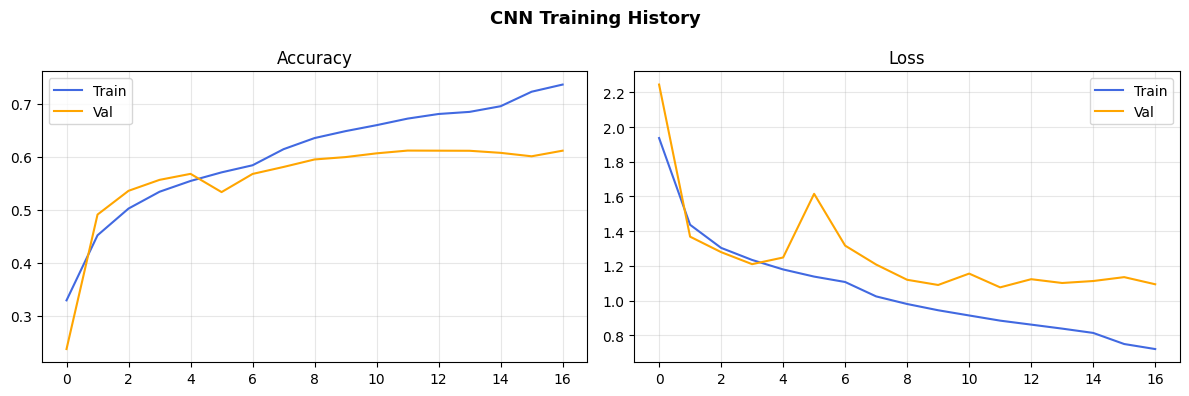

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train', color='royalblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='orange')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'],         label='Train', color='royalblue')
axes[1].plot(history.history['val_loss'],     label='Val',   color='orange')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

⚠️  No face detected — using full image.


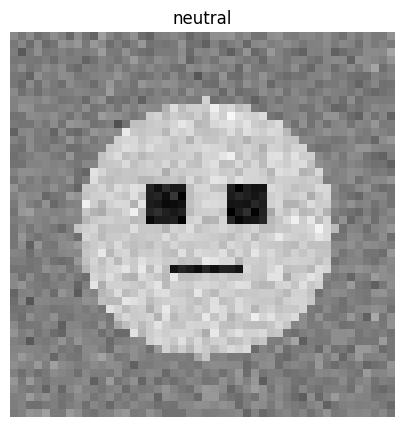

Predicted: neutral  (77.24%)


In [ ]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def predict_facial_emotion(image_path, show=True):
    img_bgr  = cv2.imread(image_path)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    faces    = face_cascade.detectMultiScale(
        img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
    draw = img_rgb.copy()
    results = []
    rois = [img_gray] if len(faces) == 0 else [
        img_gray[y:y+h, x:x+w] for x,y,w,h in faces]
    if len(faces) == 0:
        print("⚠️  No face detected — using full image.")
    for roi in rois:
        r = cv2.resize(roi, (48,48)).astype(np.float32) / 255.0
        probs = cnn_model.predict(r.reshape(1,48,48,1), verbose=0)[0]
        eid   = np.argmax(probs)
        results.append((EMOTION_LABELS[eid], probs[eid], probs))
    for (x,y,w,h), (lbl,conf,_) in zip(faces, results):
        cv2.rectangle(draw,(x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(draw,f'{lbl} {conf:.2f}',(x,max(y-10,10)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.6,(0,255,0),2)
    if show:
        plt.figure(figsize=(5,5))
        plt.imshow(draw); plt.axis('off')
        plt.title(', '.join(r[0] for r in results)); plt.show()
    return results

# ── Demo on a synthetic face ──────────────────────────────
demo_face = (make_face(3)*255).astype(np.uint8)
cv2.imwrite('/tmp/demo.png', demo_face)
res = predict_facial_emotion('/tmp/demo.png')
print(f"Predicted: {res[0][0]}  ({res[0][1]:.2%})")

# ── To use your own image, uncomment: ────────────────────
# uploaded = files.upload()
# res = predict_facial_emotion(list(uploaded.keys())[0])

In [ ]:
nltk.download('vader_lexicon', quiet=True)
vader = SentimentIntensityAnalyzer()

def preprocess_text(text):
    text = text.lower().strip()
    text = re.sub(r'[^\w\s!?\'.]+', '', text)
    return text

def analyze_sentiment(text, verbose=False):
    scores = vader.polarity_scores(preprocess_text(text))
    c = scores['compound']
    label = 'positive' if c >= 0.05 else ('negative' if c <= -0.05 else 'neutral')
    if verbose:
        print(f"  Text     : {text}")
        print(f"  Scores   : {scores}")
        print(f"  Sentiment: {label}  (compound={c:.3f})")
    return label, c, scores

demo_texts = [
    "I am so happy today! Everything is wonderful.",
    "This is the worst day of my life.",
    "The meeting is at 3 PM tomorrow.",
    "I am scared and nervous about the exam.",
    "WOW! That was absolutely amazing!",
]
print("=" * 55)
for t in demo_texts:
    analyze_sentiment(t, verbose=True)
    print("-" * 55)

  Text     : I am so happy today! Everything is wonderful.
  Scores   : {'neg': 0.0, 'neu': 0.385, 'pos': 0.615, 'compound': 0.8395}
  Sentiment: positive  (compound=0.840)
-------------------------------------------------------
  Text     : This is the worst day of my life.
  Scores   : {'neg': 0.369, 'neu': 0.631, 'pos': 0.0, 'compound': -0.6249}
  Sentiment: negative  (compound=-0.625)
-------------------------------------------------------
  Text     : The meeting is at 3 PM tomorrow.
  Scores   : {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}
  Sentiment: neutral  (compound=0.000)
-------------------------------------------------------
  Text     : I am scared and nervous about the exam.
  Scores   : {'neg': 0.5, 'neu': 0.5, 'pos': 0.0, 'compound': -0.6124}
  Sentiment: negative  (compound=-0.612)
-------------------------------------------------------
  Text     : WOW! That was absolutely amazing!
  Scores   : {'neg': 0.0, 'neu': 0.261, 'pos': 0.739, 'compound': 0.8583}
  

In [ ]:
# ── Strategy A: Rule-based ───────────────────────────────
FUSION_RULES = {
    ('happy','positive'):'happy',  ('happy','negative'):'sad',
    ('happy','neutral'):'happy',
    ('sad','positive'):'neutral',  ('sad','negative'):'sad',
    ('sad','neutral'):'sad',
    ('angry','positive'):'neutral',('angry','negative'):'angry',
    ('angry','neutral'):'angry',
    ('fear','positive'):'surprise',('fear','negative'):'fear',
    ('fear','neutral'):'fear',
    ('surprise','positive'):'happy',('surprise','negative'):'fear',
    ('surprise','neutral'):'surprise',
    ('disgust','positive'):'neutral',('disgust','negative'):'angry',
    ('disgust','neutral'):'disgust',
    ('neutral','positive'):'happy',('neutral','negative'):'sad',
    ('neutral','neutral'):'neutral',
}

def rule_fusion(face_emo, text_sent):
    return FUSION_RULES.get((face_emo.lower(), text_sent.lower()), face_emo)

print('Rule-Based Fusion Examples:')
for f, t in [('happy','positive'),('sad','positive'),
             ('angry','negative'),('neutral','positive')]:
    print(f"  face={f:<10} text={t:<10} → {rule_fusion(f,t)}")

Rule-Based Fusion Examples:
  face=happy      text=positive   → happy
  face=sad        text=positive   → neutral
  face=angry      text=negative   → angry
  face=neutral    text=positive   → happy


In [ ]:
# ── Strategy B: ML Fusion (Mini MLP) ────────────────────

def build_fusion_dataset(n=2000):
    X_f, y_f = [], []
    sent_scores = {
        'positive':[0.7,0.6,0.05,0.35],
        'negative':[-0.7,0.05,0.6,0.35],
        'neutral':[0.0,0.1,0.1,0.8]
    }
    for _ in range(n):
        fid  = np.random.randint(NUM_CLASSES)
        sent = np.random.choice(list(sent_scores))
        fp   = np.random.dirichlet(np.ones(NUM_CLASSES)*0.3)
        fp[fid] = max(fp[fid], 0.5); fp /= fp.sum()
        ts   = np.array(sent_scores[sent], np.float32)
        ts  += np.random.normal(0, 0.05, ts.shape)
        feat = np.concatenate([fp, ts])
        feid = EMOTION_LABELS.index(rule_fusion(EMOTION_LABELS[fid], sent))
        X_f.append(feat); y_f.append(feid)
    return np.array(X_f, np.float32), to_categorical(y_f, NUM_CLASSES)

Xf, yf = build_fusion_dataset(2000)
Xf_tr,Xf_te,yf_tr,yf_te = train_test_split(Xf,yf,test_size=0.2,random_state=42)

fusion_model = models.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(64, activation='relu'), layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax'),
], name='FusionMLP')
fusion_model.compile(optimizer='adam',
                     loss='categorical_crossentropy', metrics=['accuracy'])

print("🚀 Training Fusion MLP …")
fusion_model.fit(Xf_tr, yf_tr, validation_split=0.15,
                 epochs=30, batch_size=64,
                 callbacks=[EarlyStopping(patience=5,restore_best_weights=True)],
                 verbose=0)
_, fa = fusion_model.evaluate(Xf_te, yf_te, verbose=0)
print(f"✅ Fusion MLP Test Accuracy: {fa:.4f}")

def ml_fusion(face_probs, text_scores):
    t = np.array([text_scores['compound'],text_scores['pos'],
                  text_scores['neg'],text_scores['neu']], np.float32)
    feat  = np.concatenate([face_probs, t]).reshape(1,-1)
    probs = fusion_model.predict(feat, verbose=0)[0]
    eid   = np.argmax(probs)
    return EMOTION_LABELS[eid], probs[eid]

🚀 Training Fusion MLP …
✅ Fusion MLP Test Accuracy: 0.6125


⚠️  No face detected — using full image.


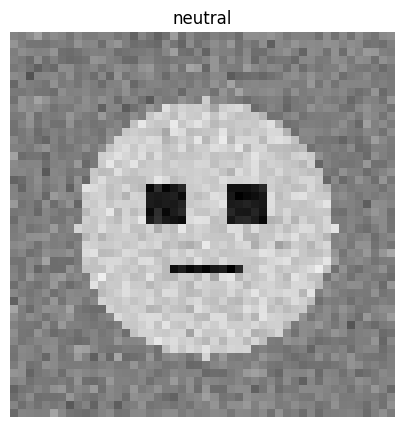


  🎭  MULTIMODAL EMOTION RESULT
  🖼️  Face Emotion  : neutral      (79.77%)
  📝  Text Sent.   : positive     (compound=0.689)
  🔀  Fusion       : rule
  ✅  Final Emotion: happy 

⚠️  No face detected — using full image.


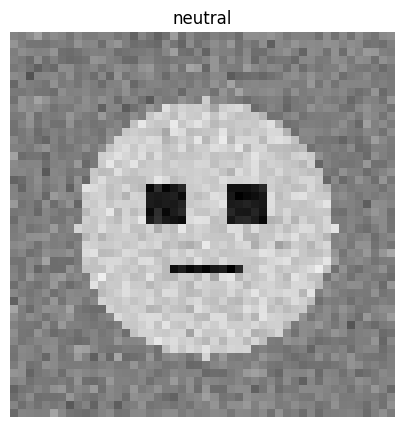


  🎭  MULTIMODAL EMOTION RESULT
  🖼️  Face Emotion  : neutral      (79.77%)
  📝  Text Sent.   : positive     (compound=0.689)
  🔀  Fusion       : ml
  ✅  Final Emotion: happy (86.53%)


('neutral', 'positive', 'happy')

In [ ]:
def multimodal_predict(image_path, text, fusion='rule'):
    # 1. Facial emotion
    face_res   = predict_facial_emotion(image_path, show=True)
    face_emo, face_conf, face_probs = face_res[0]

    # 2. Text sentiment
    text_lbl, compound, scores = analyze_sentiment(text)

    # 3. Fusion
    if fusion == 'rule':
        final_emo  = rule_fusion(face_emo, text_lbl)
        final_conf = None
    else:
        final_emo, final_conf = ml_fusion(face_probs, scores)

    # 4. Print results
    print("\n" + "="*50)
    print("  🎭  MULTIMODAL EMOTION RESULT")
    print("="*50)
    print(f"  🖼️  Face Emotion  : {face_emo:<12} ({face_conf:.2%})")
    print(f"  📝  Text Sent.   : {text_lbl:<12} (compound={compound:.3f})")
    print(f"  🔀  Fusion       : {fusion}")
    cf = f'({final_conf:.2%})' if final_conf else ''
    print(f"  ✅  Final Emotion: {final_emo} {cf}")
    print("="*50)
    return face_emo, text_lbl, final_emo

# Demo
cv2.imwrite('/tmp/test.png', (make_face(3)*255).astype(np.uint8))
multimodal_predict('/tmp/test.png', 'I feel absolutely great today!', 'rule')
print()
multimodal_predict('/tmp/test.png', 'I feel absolutely great today!', 'ml')

Upload an image (or skip):


⚠️  No face detected — using full image.


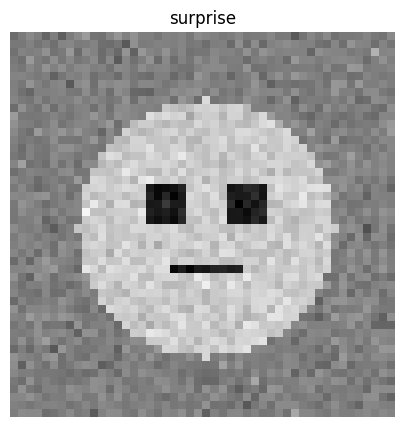


  🎭  MULTIMODAL EMOTION RESULT
  🖼️  Face Emotion  : surprise     (45.33%)
  📝  Text Sent.   : negative     (compound=-0.477)
  🔀  Fusion       : rule
  ✅  Final Emotion: fear 


In [ ]:
# Interactive: upload your own image
print('Upload an image (or skip):')
try:
    up = files.upload()
    if up:
        ipath = list(up.keys())[0]
        txt   = input('Text: ')
        multimodal_predict(ipath, txt, 'rule')
    else:
        multimodal_predict('/tmp/test.png', 'I feel sad today.', 'rule')
except Exception as e:
    print(f"Demo mode ({e})")
    multimodal_predict('/tmp/test.png', 'I feel sad today.', 'rule')

In [ ]:
y_pred = np.argmax(cnn_model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("=" * 45)
print("  CNN — EVALUATION METRICS")
print("=" * 45)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}  (weighted)")
print(f"  Recall    : {rec:.4f}  (weighted)")
print(f"  F1 Score  : {f1:.4f}  (weighted)")
print("=" * 45)
print(classification_report(y_true, y_pred,
      target_names=EMOTION_LABELS, zero_division=0))

  CNN — EVALUATION METRICS
  Accuracy  : 0.6103
  Precision : 0.6101  (weighted)
  Recall    : 0.6103  (weighted)
  F1 Score  : 0.6076  (weighted)
              precision    recall  f1-score   support

       angry       0.56      0.42      0.48       743
     disgust       0.56      0.41      0.48        82
        fear       0.44      0.41      0.43       768
       happy       0.80      0.85      0.82      1349
         sad       0.47      0.55      0.51       912
    surprise       0.75      0.70      0.73       600
     neutral       0.57      0.59      0.58       930

    accuracy                           0.61      5384
   macro avg       0.59      0.56      0.57      5384
weighted avg       0.61      0.61      0.61      5384



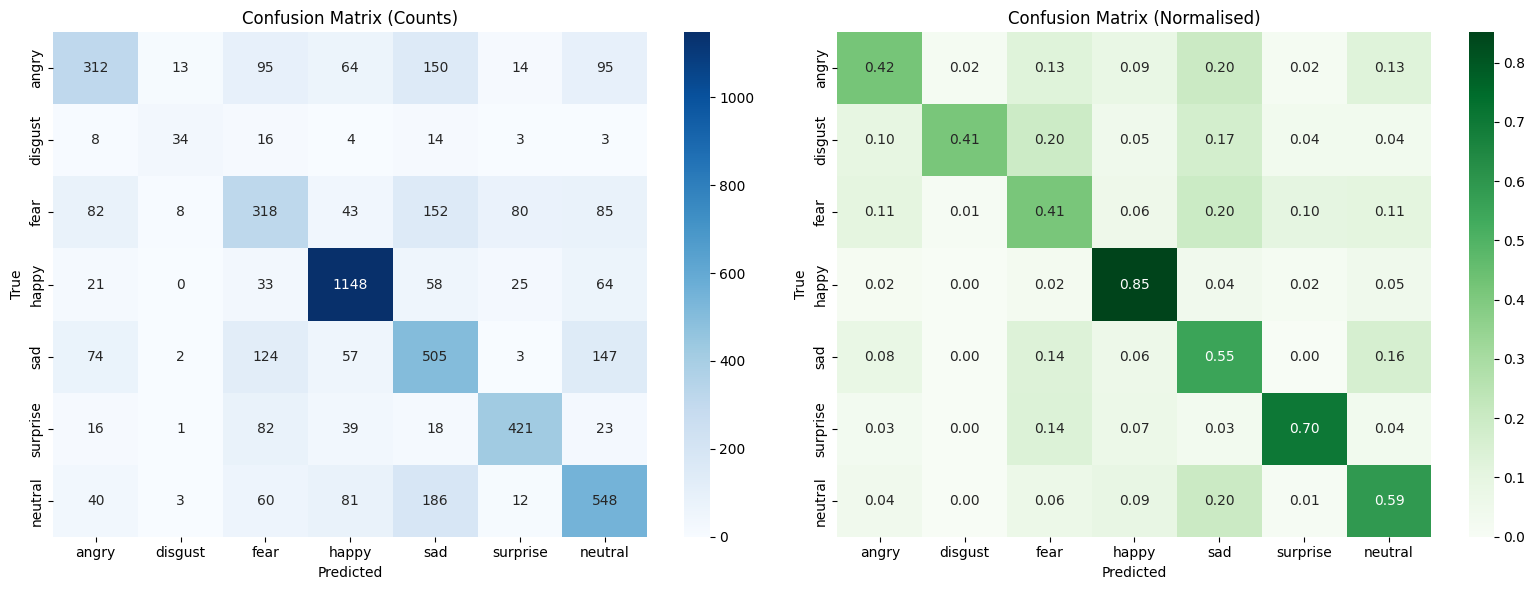

In [ ]:
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalised)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout(); plt.show()

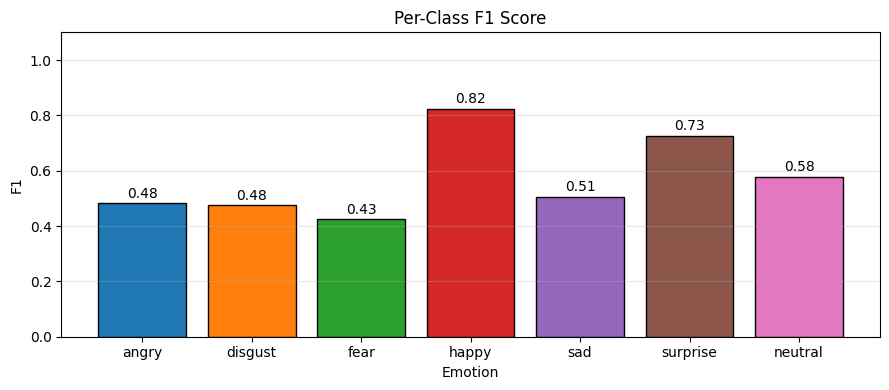

In [ ]:
f1_cls = f1_score(y_true, y_pred, average=None, zero_division=0)
plt.figure(figsize=(9,4))
bars = plt.bar(EMOTION_LABELS, f1_cls,
               color=plt.cm.tab10.colors[:NUM_CLASSES], edgecolor='black')
for bar, v in zip(bars, f1_cls):
    plt.text(bar.get_x()+bar.get_width()/2, v+0.02,
             f'{v:.2f}', ha='center', fontsize=10)
plt.ylim(0,1.1); plt.title('Per-Class F1 Score')
plt.xlabel('Emotion'); plt.ylabel('F1'); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

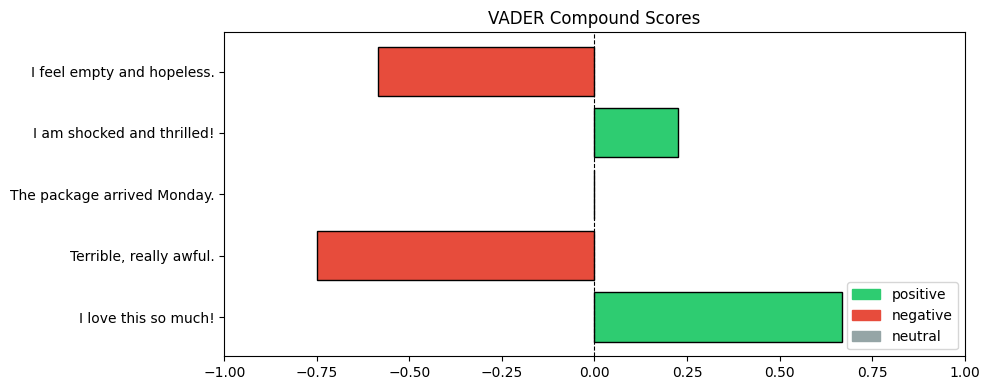

In [ ]:
texts_demo = [
    ('I love this so much!', 'positive'),
    ('Terrible, really awful.', 'negative'),
    ('The package arrived Monday.', 'neutral'),
    ('I am shocked and thrilled!', 'positive'),
    ('I feel empty and hopeless.', 'negative'),
]
cmap_s = {'positive':'#2ecc71','negative':'#e74c3c','neutral':'#95a5a6'}
compounds = []
colours   = []
for txt, true_s in texts_demo:
    _, c, _ = analyze_sentiment(txt)
    compounds.append(c); colours.append(cmap_s[true_s])

lbls = [t[:30]+'...' if len(t)>30 else t for t,_ in texts_demo]
plt.figure(figsize=(10,4))
plt.barh(lbls, compounds, color=colours, edgecolor='black')
plt.axvline(0, color='black', lw=0.8, ls='--'); plt.xlim(-1,1)
plt.title('VADER Compound Scores')
patches = [mpatches.Patch(color=v,label=k) for k,v in cmap_s.items()]
plt.legend(handles=patches, loc='lower right')
plt.tight_layout(); plt.show()

Saving img2.jpg to img2 (4).jpg


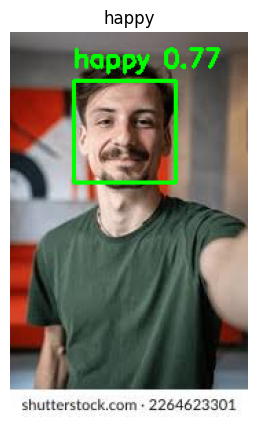


  🎭  MULTIMODAL EMOTION RESULT
  🖼️  Face Emotion  : happy        (76.69%)
  📝  Text Sent.   : positive     (compound=0.611)
  🔀  Fusion       : rule
  ✅  Final Emotion: happy 


In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Step 1: Upload your image
uploaded = files.upload()  # click "Choose Files" and select a photo

# Step 2: Get the image path
img_path = list(uploaded.keys())[0]

# Step 3: Run the full prediction
result = multimodal_predict(
    image_path = img_path,
    text = "I am happy today!",  # ← change this to match your mood
    fusion = 'rule'
)